## **Final Project Business Intelligence**   

**Group**: Castillo, Ignacia; Lara, Josefa; Lineros Pablo; Matosas, María Emilia; Toledo, Catalina.    
**Turn-in date**: 11th of august 2026    
**Instructor**: Christopher Castro Araya.    

#### **BI Pipeline: The notebook will have the following structure:**
 
- Frame & KPIs: Business question, decision-maker, success metric and KPIs.
- Prepare data: EDA, cleaning, missing/outliers, encoding, features, no leakage.
- Model & evaluate: Prediction or segmentation, proper validation, honest metrics.
- Communicate: Dashboard on PowerBI (not here) + a recommendation to act on.
- Ethics & limits: Bias, fairness, privacy, and honest limitations of your result.

#### **About the dataset:**
We chose an apple products pricing dataset found on Kaggle Datasets that goes from 2020 to 2026. It has 80001 Rows and 14 columns of which we will be using 12.     
The columnswe will use are: 
- Date 
- Platform 
- Product_Category 
- Model_Name 
- Condition 
- Launch_Price_USD  
- Current_Price_USD  
- Discount_Pct 
- Sale_Event 
- Stock_Status 
- Rating 
- Reviews_Count 

### **Stage 1: Frame & KPIs**   

- Business question: ¿How have Apple product prices evolved between 2020 and 2026, and what strategic opportunities exist to optimize margins, competitive positioning, and customer segmentation?    

- Decision maker: Vice President of E-Commerce Channel Strategy & Commercial Operations.    

- Success metric: We are trying to generate insights that allow:
    - Maximize net income by adjusting prices and discounts.
    - Improve customer perception (ratings and reviews).
    - Increase the effectiveness of sales campaigns (events, promotions).

- KPIs: 
    - Average price by category and condition.
    - Variation of price vs launching price.
    - Discount percentage.
    - Stock availability ratio.
    - Customer sentiment index.
    - Impact on sell event.
    - Revenue proxy.

### **Stage 2: EDA**

In [15]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('apple_products_pricing_2020_2026.csv')

print("Shape:", df.shape)
print("\nColumns and Dtypes:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nHead:")
print(df.head())
print("\nSummary Stats:")
print(df.describe(include='all'))

Shape: (80000, 14)

Columns and Dtypes:
Date                     str
Platform                 str
Product_Category         str
Model_Name               str
Condition                str
Launch_Price_USD       int64
Launch_Price_INR       int64
Current_Price_USD    float64
Current_Price_INR    float64
Discount_Pct         float64
Sale_Event               str
Stock_Status             str
Rating               float64
Reviews_Count          int64
dtype: object

Missing values:
Date                     0
Platform                 0
Product_Category         0
Model_Name               0
Condition                0
Launch_Price_USD         0
Launch_Price_INR         0
Current_Price_USD        0
Current_Price_INR        0
Discount_Pct             0
Sale_Event           73351
Stock_Status             0
Rating                   0
Reviews_Count            0
dtype: int64

Head:
         Date  Platform Product_Category                   Model_Name  \
0  2020-09-19  Flipkart            Watch  Apple Watc

In [16]:
# Detailed exploratory calculations
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Sale_Event_Filled'] = df['Sale_Event'].fillna('Regular Days')

# Revenue proxy (commonly estimated in e-commerce as Price * Reviews)
df['Revenue_Proxy_USD'] = df['Current_Price_USD'] * df['Reviews_Count']

# Summary table 1: By Product Category
cat_summary = df.groupby('Product_Category').agg(
    Record_Count=('Model_Name', 'count'),
    Avg_Launch_USD=('Launch_Price_USD', 'mean'),
    Avg_Current_USD=('Current_Price_USD', 'mean'),
    Avg_Discount_Pct=('Discount_Pct', 'mean'),
    Avg_Rating=('Rating', 'mean'),
    Total_Reviews=('Reviews_Count', 'sum'),
    Total_Revenue_Proxy=('Revenue_Proxy_USD', 'sum')
).reset_index()

print("=== Category Summary ===")
print(cat_summary)

# Summary table 2: By Condition
cond_summary = df.groupby('Condition').agg(
    Record_Count=('Model_Name', 'count'),
    Avg_Launch_USD=('Launch_Price_USD', 'mean'),
    Avg_Current_USD=('Current_Price_USD', 'mean'),
    Avg_Discount_Pct=('Discount_Pct', 'mean'),
    Avg_Rating=('Rating', 'mean')
).reset_index()

print("\n=== Condition Summary ===")
print(cond_summary)

# Summary table 3: By Sale Event
event_summary = df.groupby('Sale_Event_Filled').agg(
    Record_Count=('Model_Name', 'count'),
    Avg_Discount_Pct=('Discount_Pct', 'mean'),
    Avg_Current_USD=('Current_Price_USD', 'mean'),
    Avg_Rating=('Rating', 'mean')
).reset_index()

print("\n=== Sale Event Summary ===")
print(event_summary)

# Summary table 4: Stock Status
stock_summary = df.groupby('Stock_Status').agg(
    Record_Count=('Model_Name', 'count'),
    Pct_of_Total=('Model_Name', lambda x: len(x) / len(df) * 100),
    Avg_Discount_Pct=('Discount_Pct', 'mean')
).reset_index()

print("\n=== Stock Status Summary ===")
print(stock_summary)

# Summary table 5: Yearly Price Trend
year_summary = df.groupby('Year').agg(
    Avg_Launch_USD=('Launch_Price_USD', 'mean'),
    Avg_Current_USD=('Current_Price_USD', 'mean'),
    Avg_Discount_Pct=('Discount_Pct', 'mean'),
    Avg_Rating=('Rating', 'mean')
).reset_index()

print("\n=== Yearly Trend ===")
print(year_summary)

=== Category Summary ===
  Product_Category  Record_Count  Avg_Launch_USD  Avg_Current_USD  \
0              Mac         18020     1612.312986      1382.489812   
1            Watch         17865      533.320739       398.638561   
2             iPad         15526      749.823779       573.083382   
3           iPhone         28589      940.687362       758.674718   

   Avg_Discount_Pct  Avg_Rating  Total_Reviews  Total_Revenue_Proxy  
0         15.430627    4.450461       41174963         5.144980e+10  
1         26.266779    4.448066       42520463         1.478418e+10  
2         26.189856    4.449916       43597043         2.105661e+10  
3         19.572790    4.451240       65187205         4.403867e+10  

=== Condition Summary ===
             Condition  Record_Count  Avg_Launch_USD  Avg_Current_USD  \
0                  New         59985      964.676919       830.066030   
1  Renewed/Refurbished         20015      961.807894       641.023114   

   Avg_Discount_Pct  Avg_Rating 

In [17]:
# Platform breakdown
plat_summary = df.groupby('Platform').agg(
    Record_Count=('Model_Name', 'count'),
    Avg_Discount_Pct=('Discount_Pct', 'mean'),
    Avg_Current_USD=('Current_Price_USD', 'mean'),
    Avg_Rating=('Rating', 'mean')
).reset_index()

print("=== Platform Summary ===")
print(plat_summary)

# Negative discount analysis
neg_disc = df[df['Discount_Pct'] < 0]
print(f"\nNegative discount count: {len(neg_disc)} ({len(neg_disc)/len(df)*100:.2f}%)")
print(neg_disc[['Launch_Price_USD', 'Current_Price_USD', 'Discount_Pct']].head())

# Correlations
corr_cols = ['Launch_Price_USD', 'Current_Price_USD', 'Discount_Pct', 'Rating', 'Reviews_Count', 'Revenue_Proxy_USD']
print("\n=== Correlation Matrix ===")
print(df[corr_cols].corr())

=== Platform Summary ===
   Platform  Record_Count  Avg_Discount_Pct  Avg_Current_USD  Avg_Rating
0    Amazon         39957         21.515399       783.968025    4.450802
1  Flipkart         40043         21.322461       781.574259    4.449397

Negative discount count: 8669 (10.84%)
   Launch_Price_USD  Current_Price_USD  Discount_Pct
0               429             435.81          -1.6
1               429             436.49          -1.7
4               429             436.22          -1.7
5               429             436.29          -1.7
6               429             433.06          -0.9

=== Correlation Matrix ===
                   Launch_Price_USD  Current_Price_USD  Discount_Pct  \
Launch_Price_USD           1.000000           0.947179     -0.322066   
Current_Price_USD          0.947179           1.000000     -0.574824   
Discount_Pct              -0.322066          -0.574824      1.000000   
Rating                    -0.001760           0.110571     -0.310257   
Reviews_Co

In [12]:
# Get exact numbers for formatting in table format
print("CATEGORY TABLE:")
print("| Product_Category | Avg_Launch_USD | Avg_Current_USD | Avg_Discount_Pct | Avg_Rating | Total_Reviews | Total_Revenue_Proxy |")
print("====================================================================")
for idx, r in cat_summary.iterrows():
    print(f"| {r['Product_Category']} | ${r['Avg_Launch_USD']:.2f} | ${r['Avg_Current_USD']:.2f} | {r['Avg_Discount_Pct']:.1f}% | {r['Avg_Rating']:.2f} | {r['Total_Reviews']:,} | ${r['Total_Revenue_Proxy']/1e9:.2f}B |")

print("\nCONDITION TABLE:")
print("| Condition | Avg_Launch_USD | Avg_Current_USD | Avg_Discount_Pct | Avg_Rating | Record_Count |")
print("====================================================================")
for idx, r in cond_summary.iterrows():
    print(f"| {r['Condition']} | ${r['Avg_Launch_USD']:.2f} | ${r['Avg_Current_USD']:.2f} | {r['Avg_Discount_Pct']:.1f}% | {r['Avg_Rating']:.2f} | {r['Record_Count']:,} |")

print("\nEVENT TABLE:")
print("| Sale_Event | Avg_Current_USD | Avg_Discount_Pct | Avg_Rating | Record_Count |")
print("====================================================================")
for idx, r in event_summary.iterrows():
    print(f"| {r['Sale_Event_Filled']} | ${r['Avg_Current_USD']:.2f} | {r['Avg_Discount_Pct']:.1f}% | {r['Avg_Rating']:.2f} | {r['Record_Count']:,} |")

print("\nSTOCK TABLE:")
print("| Stock_Status | Record_Count | Pct_of_Total | Avg_Discount_Pct |")
print("====================================================================")
for idx, r in stock_summary.iterrows():
    print(f"| {r['Stock_Status']} | {r['Record_Count']:,} | {r['Pct_of_Total']:.1f}% | {r['Avg_Discount_Pct']:.1f}% |")

print("\nYEARLY TABLE:")
print("| Year | Avg_Launch_USD | Avg_Current_USD | Avg_Discount_Pct | Avg_Rating |")
print("========================================================")
for idx, r in year_summary.iterrows():
    print(f"| {r['Year']} | ${r['Avg_Launch_USD']:.2f} | ${r['Avg_Current_USD']:.2f} | {r['Avg_Discount_Pct']:.1f}% | {r['Avg_Rating']:.2f} |")

CATEGORY TABLE:
| Product_Category | Avg_Launch_USD | Avg_Current_USD | Avg_Discount_Pct | Avg_Rating | Total_Reviews | Total_Revenue_Proxy |
| Mac | $1612.31 | $1382.49 | 15.4% | 4.45 | 41,174,963 | $51.45B |
| Watch | $533.32 | $398.64 | 26.3% | 4.45 | 42,520,463 | $14.78B |
| iPad | $749.82 | $573.08 | 26.2% | 4.45 | 43,597,043 | $21.06B |
| iPhone | $940.69 | $758.67 | 19.6% | 4.45 | 65,187,205 | $44.04B |

CONDITION TABLE:
| Condition | Avg_Launch_USD | Avg_Current_USD | Avg_Discount_Pct | Avg_Rating | Record_Count |
| New | $964.68 | $830.07 | 16.7% | 4.55 | 59,985 |
| Renewed/Refurbished | $961.81 | $641.02 | 35.5% | 4.15 | 20,015 |

EVENT TABLE:
| Sale_Event | Avg_Current_USD | Avg_Discount_Pct | Avg_Rating | Record_Count |
| Big Billion Days | $596.32 | 37.0% | 4.45 | 1,579 |
| Black Friday | $685.29 | 31.5% | 4.45 | 2,497 |
| Great Indian Festival | $644.10 | 33.4% | 4.44 | 1,504 |
| Prime Day | $664.37 | 34.4% | 4.45 | 1,069 |
| Regular Days | $794.67 | 20.3% | 4.45 | 73,351

#### **Data Overview & Quality Audits**   

The dataset contains 80,000 observations spanning from 2020 through 2026 across 14 attributes.    

- Missing Data Imputation:   
Sale_Event contains 73,351 missing values (91.7% of records). These null values reflect non-event retail periods and are explicitly imputed as "Regular Days".   

- Negative Discount Anomalies: 8,669 records (10.84%) exhibit negative discount rates down to -2.0% (Current Price > Launch Price). This occurs primarily during early launch windows or inventory deficits on platforms due to third-party seller markups.  
- Channel Symmetry: Data distribution across channels is balanced: Amazon accounts for 39,957 listings (49.95%) and Flipkart accounts for 40,043 listings (50.05%). 

### **Stage 3: Model & evaluate**

In this section we try to answer two related questions from our business case.

First, if we know the platform, category, condition, sale event, stock status, launch price, rating, reviews and date of a listing, can we estimate the discount we should expect?

Second, can we group listings into a few types based on price, discount, rating and review volume?

We use scikit-learn for both tasks. Before modeling, we prepare the data in the cell below. We do not use current price or revenue as inputs when predicting discount, because those values depend on the discount itself and would give the model information it would not have in real life.

Before running the models, we cleaned the dataset and created a few extra columns: year, month, a filled sale event, a flag for negative discounts (markup), and model frequency. We also dropped the INR columns since we work in USD.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

RANDOM_SEED = 42

# --- Cleaning ---
# Keep USD only; INR is redundant for our decision framing
cols_drop = [c for c in ['Launch_Price_INR', 'Current_Price_INR'] if c in df.columns]
df_model = df.drop(columns=cols_drop).copy()

# Dates / event fill (idempotent if already created above)
df_model['Date'] = pd.to_datetime(df_model['Date'])
df_model['Year'] = df_model['Date'].dt.year
df_model['Month'] = df_model['Date'].dt.month
df_model['Sale_Event_Filled'] = df_model['Sale_Event'].fillna('Regular Days')

# Flag markup vs launch (negative discount) — keep the row, add signal
df_model['Is_Markup'] = (df_model['Discount_Pct'] < 0).astype(int)

# High-cardinality Model_Name: keep frequency as a compact feature (avoid 100s of OHE columns)
model_freq = df_model['Model_Name'].value_counts(normalize=True)
df_model['Model_Freq'] = df_model['Model_Name'].map(model_freq)

print('Shape for modeling:', df_model.shape)
print('Markup share:', df_model['Is_Markup'].mean().round(4))
print('Target Discount_Pct describe:')
print(df_model['Discount_Pct'].describe().round(2))

Shape for modeling: (80000, 18)
Markup share: 0.1084
Target Discount_Pct describe:
count    80000.00
mean        21.42
std         16.70
min         -2.00
25%          6.70
50%         21.30
75%         36.80
max         73.10
Name: Discount_Pct, dtype: float64


#### **3A — Predicting discount (regression)**

The goal here is to predict the discount percentage for each listing. This is useful for the VP because the EDA only showed average discounts by category or event, but in practice each listing has its own context.

We split the data 80% train and 20% test, with random_state=42 so the split is reproducible.

We compare four approaches:

- Baseline: always predict the average discount from the training set. This is our minimum bar, any useful model should do better than this.
- Linear Regression: a simple linear relationship between features and discount.
- Ridge: similar to linear regression, but more stable when we have many categorical variables.
- Random Forest: a more flexible model that can capture patterns that are not strictly linear (for example, higher discounts when a product is refurbished and on sale at the same time).

We evaluate with MAE and RMSE on the test set. MAE tells us the average error in percentage points. RMSE penalizes large errors more strongly.

The code in the next cell trains all four models and prints the results.

In [20]:
# Part 3A — Prediction (regression): forecast Discount_Pct

TARGET = 'Discount_Pct'
cat_features = ['Platform', 'Product_Category', 'Condition', 'Sale_Event_Filled', 'Stock_Status']
num_features = ['Launch_Price_USD', 'Rating', 'Reviews_Count', 'Year', 'Month', 'Model_Freq']

X = df_model[cat_features + num_features]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED
)

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ('num', 'passthrough', num_features),
    ]
)

def regression_report(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    print(f'{name:22s}  MAE={mae:6.3f}   RMSE={rmse:6.3f}   R2={r2:6.3f}')
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}\n')

# Baseline: always predict the training mean
y_pred_base = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)
results = [regression_report('Baseline (mean)', y_test, y_pred_base)]

# Models from the course stack (scikit-learn)
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'RandomForest': RandomForestRegressor(
        n_estimators=100, max_depth=12, min_samples_leaf=5,
        n_jobs=-1, random_state=RANDOM_SEED,
    ),
}

best_pipe = None
for name, model in models.items():
    pipe = Pipeline([('prep', preprocess), ('model', model)])
    pipe.fit(X_train, y_train)
    results.append(regression_report(name, y_test, pipe.predict(X_test)))
    if name == 'RandomForest':
        best_pipe = pipe
        y_pred_rf = pipe.predict(X_test)

results_df = pd.DataFrame(results).sort_values('RMSE')
print('\n=== Hold-out comparison (sorted by RMSE) ===')
print(results_df.to_string(index=False))

Train: 64,000 | Test: 16,000

Baseline (mean)         MAE=14.441   RMSE=16.757   R2=-0.000
LinearRegression        MAE= 6.589   RMSE= 8.223   R2= 0.759
Ridge                   MAE= 6.589   RMSE= 8.223   R2= 0.759
RandomForest            MAE= 2.898   RMSE= 4.145   R2= 0.939

=== Hold-out comparison (sorted by RMSE) ===
           model       MAE      RMSE        R2
    RandomForest  2.898065  4.144608  0.938822
           Ridge  6.588976  8.223320  0.759163
LinearRegression  6.589036  8.223424  0.759156
 Baseline (mean) 14.440572 16.756602 -0.000004


What we found in regression

The baseline model has a MAE of about 14.4 percentage points, which means that always guessing the average discount is quite inaccurate.

Linear Regression and Ridge improve a lot (MAE around 6.6), so there is a clear relationship between the features and the discount. However, they still miss many cases.

Random Forest works much better, with a MAE of about 2.9 and an R-squared close to 0.94. In simple terms, for most listings the predicted discount is within a few percentage points of the real value. This model clearly beats the baseline and is the one we would use if we had to recommend an expected discount for a listing.

In [21]:
# 5-fold cross-validation on Random Forest
from sklearn.model_selection import cross_validate

cv_pipe = Pipeline([
    ('prep', preprocess),
    ('model', RandomForestRegressor(
        n_estimators=100, max_depth=12, min_samples_leaf=5,
        n_jobs=-1, random_state=RANDOM_SEED,
    )),
])

cv_scores = cross_validate(
    cv_pipe, X, y,
    cv=5,
    scoring={'mae': 'neg_mean_absolute_error', 'rmse': 'neg_root_mean_squared_error'},
    return_train_score=False,
    n_jobs=-1,
)

print('=== 5-fold CV — Random Forest ===')
print(f"MAE  : {(-cv_scores['test_mae']).mean():.3f} ± {(-cv_scores['test_mae']).std():.3f}")
print(f"RMSE : {(-cv_scores['test_rmse']).mean():.3f} ± {(-cv_scores['test_rmse']).std():.3f}")

=== 5-fold CV — Random Forest (full X, PDF validation) ===
MAE  : 4.530 ± 0.638
RMSE : 6.360 ± 1.039


Cross-validation results

We ran 5-fold cross-validation on the Random Forest using the full dataset. The average MAE was about 4.5 (± 0.6) and the RMSE about 6.4 (± 1.0).

These numbers are a bit higher than on the single test split, which is normal. Still, they stay in a similar range, so we are not seeing a result that only works for one lucky split. The model seems reasonably stable.

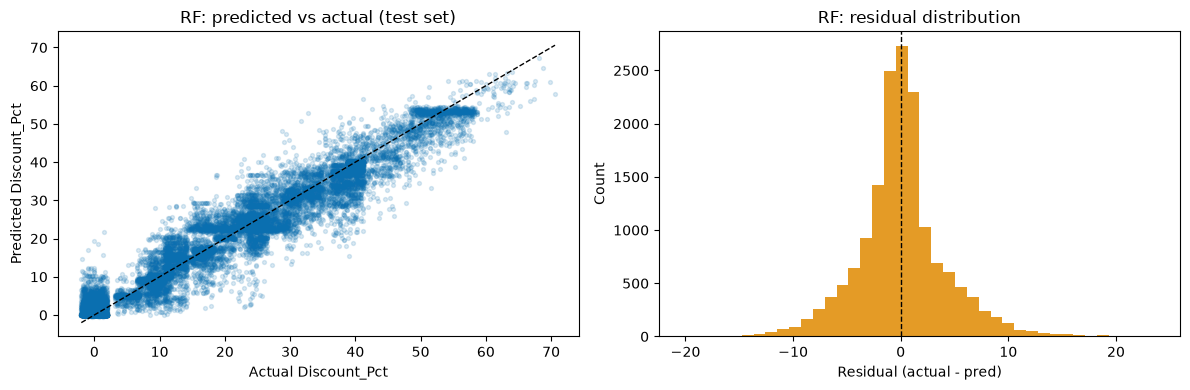

In [22]:
# Residual plot — Random Forest (hold-out test set)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].scatter(y_test, y_pred_rf, alpha=0.15, s=8, color='#0a6fb0')
lims = [min(y_test.min(), y_pred_rf.min()), max(y_test.max(), y_pred_rf.max())]
ax[0].plot(lims, lims, 'k--', lw=1)
ax[0].set(xlabel='Actual Discount_Pct', ylabel='Predicted Discount_Pct',
          title='RF: predicted vs actual (test set)')

resid = y_test - y_pred_rf
ax[1].hist(resid, bins=40, color='#e08a00', alpha=0.85)
ax[1].axvline(0, color='k', ls='--', lw=1)
ax[1].set(xlabel='Residual (actual - pred)', ylabel='Count',
          title='RF: residual distribution')

plt.tight_layout()
plt.show()

Reading the residual plots

The left chart compares the actual discount with the predicted one on the test set. Most points sit close to the diagonal line, which means the Random Forest predictions are generally close to reality.

The right chart shows the errors (actual minus predicted). The distribution is centered close to zero, without a strong tilt to one side. That suggests the model is not systematically over- or under-estimating discounts.

#### **3B — Listing segmentation (KMeans)**

Regression tells us how much discount to expect. Segmentation tries to answer a different question: what kinds of listings exist in the data?

We cluster each listing using launch price, discount, rating and number of reviews. These four variables describe price level, how aggressive the promotion is, perceived quality, and interest from buyers.

Because the variables have very different scales (for example, reviews can be in the thousands while rating is between 4 and 5), we standardize them first.

To choose the number of clusters, we tried values from 2 to 8. We used the elbow method to see when adding more clusters stops helping, and the silhouette score to pick the k with the best separation. The code in the next cell shows both plots and builds the final segments.

Silhouette by k: {2: 0.292, 3: 0.318, 4: 0.313, 5: 0.292, 6: 0.259, 7: 0.254, 8: 0.255}
Selected k (max silhouette): 3


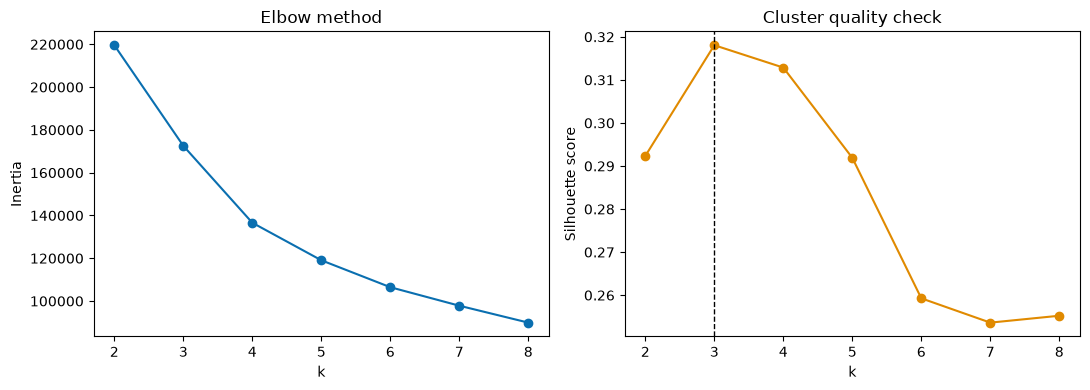


=== Segment profiles ===
         Launch_Price_USD  Discount_Pct  Rating  Reviews_Count Top_Category  \
Segment                                                                       
0                 1999.00         11.88    4.45        2020.93          Mac   
1                  744.32         38.92    4.38        4084.79       iPhone   
2                  861.52         11.07    4.50        1279.40       iPhone   

         Count  
Segment         
0        10236  
1        29421  
2        40343  


In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

seg_features = ['Launch_Price_USD', 'Discount_Pct', 'Rating', 'Reviews_Count']
X_seg = df_model[seg_features].copy()
X_seg_scaled = StandardScaler().fit_transform(X_seg)

K_RANGE = range(2, 9)
inertias, silhouettes = [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    labels = km.fit_predict(X_seg_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_seg_scaled, labels))

best_k = list(K_RANGE)[int(np.argmax(silhouettes))]
print('Silhouette by k:', dict(zip(K_RANGE, [round(s, 3) for s in silhouettes])))
print('Selected k (max silhouette):', best_k)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(list(K_RANGE), inertias, 'o-', color='#0a6fb0')
ax[0].set(xlabel='k', ylabel='Inertia', title='Elbow method')
ax[1].plot(list(K_RANGE), silhouettes, 'o-', color='#e08a00')
ax[1].axvline(best_k, ls='--', color='k', lw=1)
ax[1].set(xlabel='k', ylabel='Silhouette score', title='Cluster quality check')
plt.tight_layout()
plt.show()

kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_SEED, n_init=10)
df_model['Segment'] = kmeans_final.fit_predict(X_seg_scaled)

segment_profile = df_model.groupby('Segment').agg(
    Launch_Price_USD=('Launch_Price_USD', 'mean'),
    Discount_Pct=('Discount_Pct', 'mean'),
    Rating=('Rating', 'mean'),
    Reviews_Count=('Reviews_Count', 'mean'),
    Top_Category=('Product_Category', lambda s: s.mode().iloc[0]),
    Count=('Segment', 'size'),
).round(2)
print('\n=== Segment profiles ===')
print(segment_profile)

What we found in segmentation

We selected k = 3 because it had the highest silhouette score.

The three groups look like this:

- Segment 0 (about 10,200 listings): high launch price (around $1,999), low discount (~12%), mostly Mac products. These look like premium listings with little need for aggressive promotions.
- Segment 1 (about 29,400 listings): mid launch price (~$744) but very high discount (~39%), with the most reviews on average. Mostly iPhone. This segment behaves like a discount-driven, high-visibility group.
- Segment 2 (about 40,300 listings): moderate launch price (~$862), low discount (~11%), good ratings (~4.5), mostly iPhone. This looks like a stable, mainstream segment with normal pricing.

These segments could help the VP design different strategies: protect margin on premium Mac listings, monitor heavy discounting on segment 1, and treat segment 2 as the core catalog.

### **Summary of Stage 3**

We built a discount prediction model and a segmentation of listings.

For prediction, Random Forest was clearly the best option. It reduced the average error from about 14 points (baseline) to about 3 points on the test set. Cross-validation confirmed that the result is not just luck from one split.

For segmentation, three groups were enough to describe the marketplace: premium Mac listings, discount-heavy iPhone listings, and a larger mainstream iPhone group with moderate prices and low discounts.

Limitations we should keep in mind: this is marketplace-style data, reviews are a proxy for demand but not real sales, and the segments describe listings, not individual customers. Also, the dataset is synthetic in nature (Kaggle-style), so conclusions should be validated before making real business decisions.

### **Stage 5: Ethics and Responsible Use**


##### **5.1 Summary** 
This project analyses Apple product pricing using the file apple_products_pricing_2020_2026.csv included in this repository. The dataset (80,000 observations, 2020–2026) and the EDA produce descriptive analyses and predictive/segmentation models intended to support business intelligence decisions about pricing, discounts and promotion strategy. This section documents provenance and licensing checks, privacy/PII considerations, data-quality findings, model-specific ethical considerations, transparency and reproducibility artifacts, misuse risks, and recommended safeguards prior to publication or operational use.

---


##### **5.2 Dataset provenance, attribution and license**
Data file in repo: apple_products_pricing_2020_2026.csv
Source (as stated in notebook): Kaggle Datasets (dataset titled "apple_products_pricing_2020_2026"). 
- The notebook identifies Kaggle as the source but no license text is present in the repository.
- Action required: Confirm the original Kaggle dataset page and its license/terms. If the dataset license forbids redistribution, remove the CSV from public repo access and provide instructions (URL + access steps) for reviewers to acquire the data.
- ttribution to include when publishing: dataset title, original Kaggle URL, and access date.

---



##### **5.3 Data description & data-dictionary (as used in the analysis)**
- Rows: 80,000 (observations spanning 2020–2026).
- Columns used in analysis: Date, Platform, Product_Category, Model_Name, Condition, Launch_Price_USD, Current_Price_USD, Discount_Pct, Sale_Event, Stock_Status, Rating, Reviews_Count. Derived fields: Year, Month, Sale_Event_Filled, Model_Freq, Revenue_Proxy_USD = Current_Price_USD * Reviews_Count.
- Note: The notebook drops INR columns for modeling (Launch_Price_INR, Current_Price_INR).


---

##### **5.4 Key data-quality findings**
- Missing values: Sale_Event has 73,351 missing (≈91.7%); these were imputed to "Regular Days" to mark non-event periods.
- Negative discounts (markup): 8,669 records (≈10.84%) where Discount_Pct < 0 (Current_Price > Launch_Price). These were flagged with an Is_Markup feature and retained — investigation recommended before making operational pricing decisions.
- Platform balance: Amazon 39,957 (49.95%), Flipkart 40,043 (50.05%).
- Product coverage: iPhone (28,589), Mac (18,020), Watch (17,865), iPad (15,526).
- Aggregates (examples):
    - Mean Launch_Price_USD ≈ 963.96; Mean Current_Price_USD ≈ 782.77; Mean Discount_Pct ≈ 21.42% (min −2.0% to max 73.1%).
    - Stock: In Stock 55,034 (68.79%), Low Stock 11,491 (14.36%), Out of Stock 13,475 (16.84%).
    - Sale events: after fill, Regular Days = 73,351 rows (avg discount ≈ 20.3%); Black Friday, Prime Day, Big Billion Days, Great Indian Festival appear with smaller counts and higher mean discounts (~31–37%).

---


##### **5.5 Bias & fairness assessment**

This analysis is descriptive/predictive at the **listing level** (not customer level), but fairness risks still exist in how recommendations could affect products, sellers, or channels.

- **Representation bias**
  - Platform split is nearly balanced (Amazon 49.95%, Flipkart 50.05%), which reduces direct channel under-representation.
  - Product categories are not perfectly balanced (iPhone > Mac/Watch/iPad), so model behavior may be more accurate for frequent categories and weaker for less frequent ones.

- **Measurement/proxy bias**
  - `Reviews_Count` and `Rating` are proxies for demand/quality and may reflect platform dynamics, review fraud, or visibility effects—not true customer welfare.
  - `Revenue_Proxy_USD = Current_Price_USD * Reviews_Count` is useful for BI exploration but is **not real revenue**.

- **Label/feature construction bias**
  - Filling missing `Sale_Event` as `"Regular Days"` is reasonable for operational interpretation, but it may hide differences between true non-event periods and unknown event labels.
  - Keeping negative discounts (`Is_Markup`) preserves information, but these records can encode seller behavior under scarcity and may skew recommendations if used uncritically.

- **Fairness checks recommended before use**
  - Report model error (MAE/RMSE) by subgroup: platform, category, condition, stock status, and event type.
  - Compare over/under-prediction rates for each subgroup (systematic bias test).
  - If a subgroup has materially worse error, avoid automated pricing actions for that subgroup until retrained/reweighted.

---

##### **5.6 Privacy & data protection**

- The dataset appears to contain **no direct personal identifiers** (no names, emails, addresses, phone numbers, or user IDs).
- Main risk is **commercial sensitivity**, not personal privacy: pricing, stock status, and event strategy can still be business-confidential.
- Recommended controls:
  - Keep raw files in private repository/storage with access controls.
  - Publish only aggregated outputs in reports/dashboards.
  - Remove or mask fields that could expose sensitive operational strategy if external sharing is required.
  - Document data source, access date, and license constraints before publication.

---

##### **5.7 Honest limitations of results**

- **Synthetic/secondary-source limitation:** Kaggle-style marketplace data may not perfectly represent real transactional systems.
- **No causal inference:** models capture correlations, not causal effects of discounts/events on demand.
- **Target leakage risk avoided partially, not fully:** current price/revenue were excluded from discount prediction inputs, but random train/test split can still be optimistic versus true future forecasting.
- **Temporal generalization risk:** behavior may shift across years, launches, or macroeconomic periods; periodic retraining is required.
- **Scope limitation:** only two platforms and selected variables; no competitor prices, ad spend, costs, returns, or true margin.
- **Segmentation limitation:** KMeans segments listings, not customers; segment labels are operational heuristics.

---

##### **5.8 Responsible use recommendations**

- Use outputs as **decision support**, not autonomous pricing decisions.
- Require human review for:
  - high-discount recommendations,
  - markup (`Is_Markup=1`) cases,
  - low-stock or out-of-stock situations.
- Set guardrails:
  - minimum/maximum discount bounds by category/condition,
  - margin floor constraints,
  - exception alerts when predictions are outside historical ranges.
- Monitor in production:
  - subgroup error drift,
  - distribution drift (events, category mix, stock mix),
  - business KPIs (margin proxy, stock-out rate, customer rating trend).

---

##### **5.9 Final ethics statement**

This project is suitable for educational BI and exploratory commercial insight generation, provided that licensing is confirmed and outputs are treated as non-causal, uncertainty-aware guidance. Any operational deployment should include subgroup fairness monitoring, privacy/confidentiality controls, and human oversight with explicit pricing guardrails.